# PADI Tabular — FPR Validity Check

Validate that SI p-values are uniformly distributed under H₀.

**Protocol:**
1. Train DeepSVDD on normal data
2. Repeat N times: generate normal data → detect false anomalies → compute SI p-value
3. Check: FPR ≈ α, ECDF ≈ diagonal, KS test passes


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../..'))

import numpy as np
import torch
from padi.PADI_tabular.si_padi import compute_p_value_one_vs_mean
from padi.PADI_tabular.gen_data import generate_data, CustomDataset
from padi.PADI_tabular.model import DeepSVDD


In [2]:
# --- CONFIGURATION ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_FEATURES = 10
N_TRAIN = 500
N_TEST_PER_REP = 200
N_REFS = 10
SIGMA = 1.0
ALPHA = 0.05

HIDDEN_DIMS = (32, 16, 8)
REPDIM = 16
N_EPOCHS_AE = 50
N_EPOCHS_SVDD = 100
BATCH_SIZE = 64
QUANTILE = 0.75

MAX_PVALUES = 500

model_path = f'../model/deepsvdd_tabular_d{N_FEATURES}_r{REPDIM}.pth'
print(f'Device: {DEVICE}, model_path: {model_path}')


Device: cpu, model_path: ../model/deepsvdd_tabular_d10_r16.pth


## 1. Build or Load Model

In [3]:
if os.path.exists(model_path):
    print(f'Loading model from {model_path}...')
    model = DeepSVDD(device=DEVICE)
    model.load_model(model_path, device=DEVICE)
else:
    print('Training DeepSVDD from scratch...')

    X_train, y_train = generate_data(N_TRAIN, N_FEATURES, num_anomalies=0,
                                      delta=0, mu=0, sigma=SIGMA)
    train_set = CustomDataset(X_train, y_train)

    model = DeepSVDD(objective='one-class', device=DEVICE)
    model.set_network(in_features=N_FEATURES, repdim=REPDIM, hidden_dims=HIDDEN_DIMS)
    model.pretrain(train_set, n_epochs=N_EPOCHS_AE, batch_size=BATCH_SIZE, device=DEVICE)
    model.init_network_weights_from_pretraining()
    model.train(train_set, n_epochs=N_EPOCHS_SVDD, batch_size=BATCH_SIZE, device=DEVICE)
    model.compute_radius(train_set, quantile=QUANTILE, device=DEVICE)

    os.makedirs('../model', exist_ok=True)
    model.save_model(model_path)
    print(f'Model saved to {model_path}')

center_c = model.c.cpu().numpy()
R_squared = model.R_squared
net = model.net.cpu()
net.eval()
print(f'R² = {R_squared:.6f}')


Loading model from ../model/deepsvdd_tabular_d10_r16.pth...
Network created: in=10, hidden=(32, 16, 8), rep=16
Model loaded from ../model/deepsvdd_tabular_d10_r16.pth
R² = 0.050421


## 2. Collect P-values under H₀

In [4]:
# Normal reference pool (generated once)
X_ref_pool, _ = generate_data(N_TRAIN, N_FEATURES, num_anomalies=0,
                               delta=0, mu=0, sigma=SIGMA)


list_p_value = []
failures = {"no_detection": 0, "si_failed": 0}
total_attempts = 0

while len(list_p_value) < MAX_PVALUES:
    total_attempts += 1

    # Generate fresh normal test data (no anomalies)
    X_test, _ = generate_data(N_TEST_PER_REP, N_FEATURES, num_anomalies=0,
                               delta=0, mu=0, sigma=SIGMA)

    # Sample N_REFS from the reference pool
    idx_ref = np.random.choice(len(X_ref_pool), N_REFS, replace=False)
    X_refs = X_ref_pool[idx_ref]

    # Detect anomalies
    X_tensor = torch.from_numpy(X_test).float()
    O_test, _, _ = model.anomaly_detection_fixed_radius(X_tensor, R_squared)

    if len(O_test) == 0:
        failures["no_detection"] += 1
        continue

    j = int(np.random.choice(O_test))

    p_value = compute_p_value_one_vs_mean(
        X_test[j], X_refs, SIGMA, net, R_squared, center_c,
        return_failure_reason=False)

    if p_value is None:
        failures["si_failed"] += 1
        continue

    list_p_value.append(p_value)

    if len(list_p_value) % 100 == 0:
        current_fpr = np.mean(np.array(list_p_value) < ALPHA)
        print(f"  [{len(list_p_value):4d}/{MAX_PVALUES}] "
              f"FPR={current_fpr:.4f}  last_p={p_value:.4e}")

print(f"\nCollected {len(list_p_value)} p-values in {total_attempts} attempts")
print(f"Failures: {failures}")


  [ 100/500] FPR=0.0400  last_p=4.7993e-01


  [ 200/500] FPR=0.0450  last_p=9.3551e-01


  [ 300/500] FPR=0.0467  last_p=6.8631e-01


  [ 400/500] FPR=0.0450  last_p=5.3776e-01


  [ 500/500] FPR=0.0520  last_p=1.3285e-01

Collected 500 p-values in 500 attempts
Failures: {'no_detection': 0, 'si_failed': 0}


## 3. Results

FPR at α=0.05: 0.0520 (expected ≈ 0.05)
KS test: statistic=0.0374, p-value=0.4742
Uniform? YES ✓
Mean p-value: 0.5136


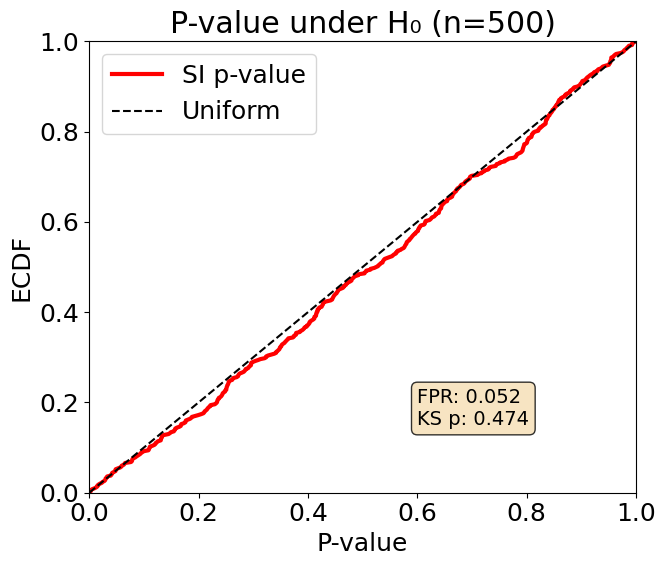

In [5]:
import scipy.stats
import matplotlib.pyplot as plt

if len(list_p_value) > 0:
    p_values = np.array(list_p_value)

    # FPR
    fpr = np.mean(p_values < ALPHA)
    ks_stat, ks_pval = scipy.stats.kstest(p_values, 'uniform')

    print(f"FPR at α={ALPHA}: {fpr:.4f} (expected ≈ {ALPHA})")
    print(f"KS test: statistic={ks_stat:.4f}, p-value={ks_pval:.4f}")
    print(f"Uniform? {'YES ✓' if ks_pval > 0.05 else 'NO ✗'}")
    print(f"Mean p-value: {np.mean(p_values):.4f}")

    # ECDF plot
    plt.rcParams.update({"font.size": 18})
    p_sorted = np.sort(p_values)
    ecdf_y = np.arange(1, len(p_sorted) + 1) / len(p_sorted)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(p_sorted, ecdf_y, 'r-', linewidth=3, label='SI p-value')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Uniform')
    ax.set_xlabel('P-value')
    ax.set_ylabel('ECDF')
    ax.set_title(f'P-value under H₀ (n={len(p_values)})')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    ax.text(0.6, 0.15, f'FPR: {fpr:.3f}\nKS p: {ks_pval:.3f}',
            fontsize=14, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig('fpr_validity_tabular.png', dpi=150)
    plt.show()
else:
    print("No p-values collected — try more iterations or adjust R²")
